Loading data...
  OHD: 43 points
  DESI BAO: 13 measurements
  Pantheon+ covariance Cholesky failed; using pseudo-inverse.
  Pantheon+: 1701 supernovae (fast factor precomputed)

Running MCMC (OHD + Pantheon+ + BAO + CMB) – optimized...


100%|████████████████████████████████████| 5000/5000 [3:09:45<00:00,  2.28s/it]



FINAL RESULTS: OHD + Pantheon+ + DESI BAO + Planck CMB
q₀ = -0.400 ± 0.000
q₁ = 0.800 ± 0.000
Ω_m = 0.200 ± 0.000
M_B = -19.999 ± 0.001
Transition redshift (q=0): z_t ≈ 0.41


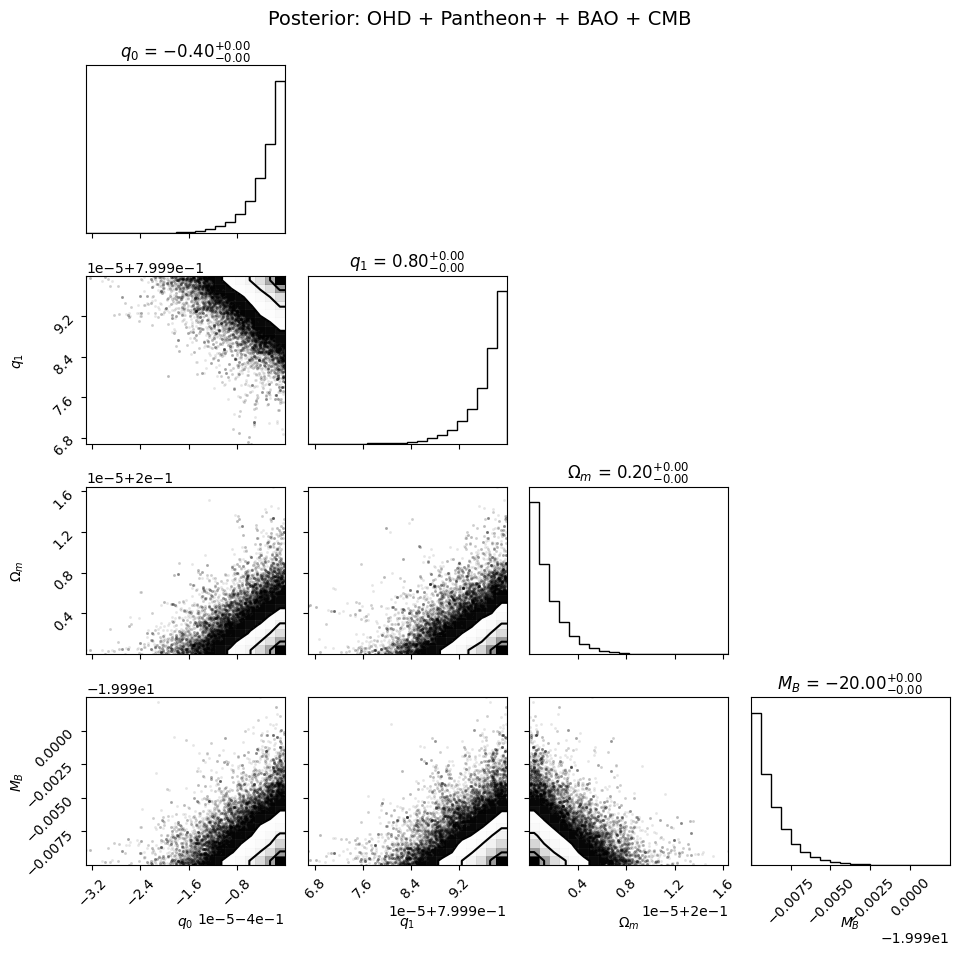

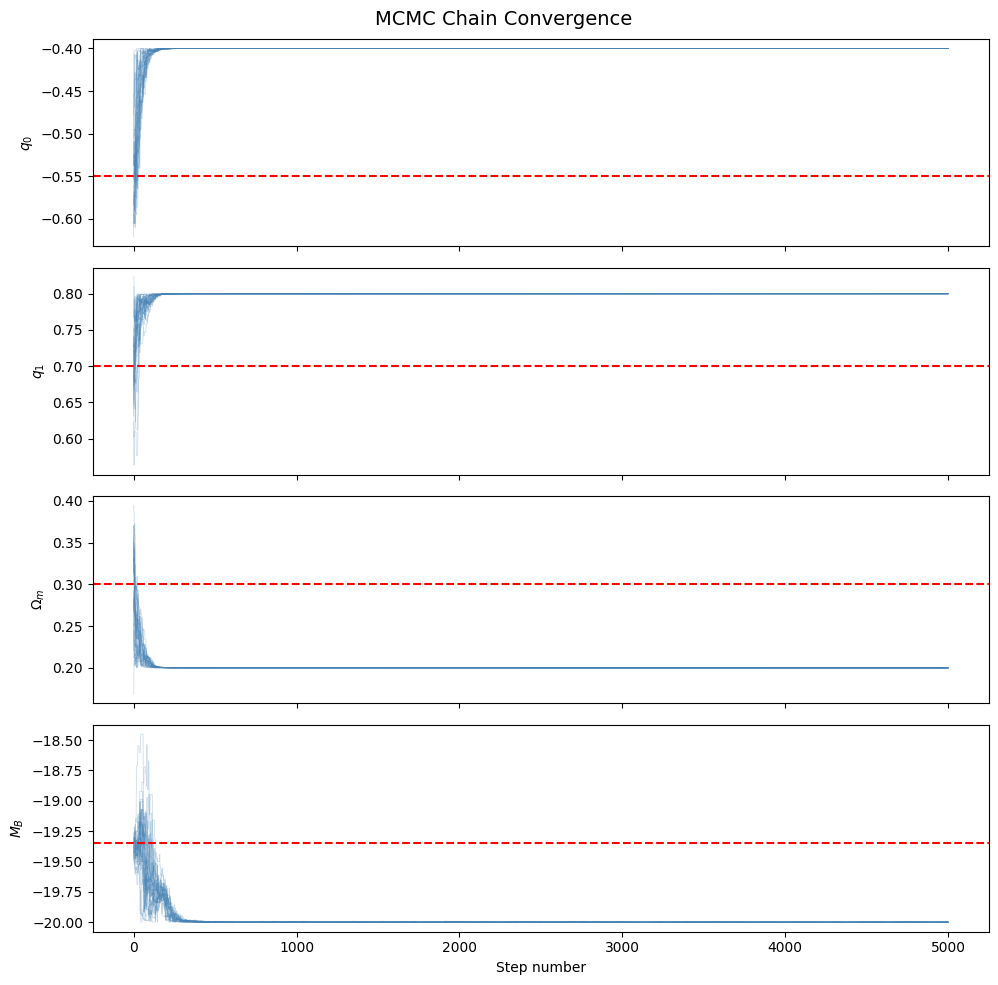


Done.


In [2]:
# =============================================================================
# FULL ANALYSIS: OHD + Pantheon+ (1701 SNe) + DESI BAO + Planck CMB (2018)
# Model: Weyl-type f(Q,T) gravity with divergence-free deceleration parameter
# Parameters: q0, q1, Omega_m, M_B
# =============================================================================

import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import quad
import math
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. COSMOLOGICAL FUNCTIONS (your f(Q,T) model)
# -----------------------------------------------------------------------------

def hubble_z(z, q0, q1, H0=70):
    """H(z) from Eq. 22: H0 (1+z)^{1+q0} (1+z^2)^{q1/2}"""
    return H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1 / 2)

def comoving_distance(z, q0, q1, H0=70):
    """Comoving distance DC(z) = ∫_0^z c/H(z') dz' (Mpc)"""
    c = 299792.458
    if np.isscalar(z):
        def integrand(zp): return c / hubble_z(zp, q0, q1, H0)
        res, _ = quad(integrand, 0, z)
        return res
    else:
        res = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp): return c / hubble_z(zp, q0, q1, H0)
            res[i], _ = quad(integrand, 0, zi)
        return res

def angular_diameter_distance(z, q0, q1, H0=70):
    return comoving_distance(z, q0, q1, H0) / (1 + z)

def luminosity_distance(z, q0, q1, H0=70):
    """Luminosity distance dL(z) = c(1+z)∫_0^z dz'/H(z') (Mpc)"""
    c = 299792.458
    if np.isscalar(z):
        def integrand(zp): return 1.0 / hubble_z(zp, q0, q1, H0)
        integral, _ = quad(integrand, 0, z)
        return c * (1 + z) * integral
    else:
        dL = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp): return 1.0 / hubble_z(zp, q0, q1, H0)
            integral, _ = quad(integrand, 0, zi)
            dL[i] = c * (1 + zi) * integral
        return dL

def distance_modulus_theory(z, q0, q1, H0=70):
    """Distance modulus μ = 5 log10(dL/1Mpc) + 25"""
    dL = luminosity_distance(z, q0, q1, H0)
    return 5 * np.log10(dL) + 25

# -----------------------------------------------------------------------------
# 2. CMB FUNCTIONS (Eisenstein & Hu 1998 sound horizon)
# -----------------------------------------------------------------------------

Z_STAR = 1090.0
R_OBS = 1.7502
LA_OBS = 301.471
OMBH2_OBS = 0.02236
T_CMB = 2.726

inv_cov_cmb = np.array([
    [ 3.600e3, -8.500e2,  6.000e4],
    [-8.500e2,  2.150e3, -1.500e4],
    [ 6.000e4, -1.500e4,  2.000e7]
])

def sound_horizon_eisenstein_hu(Om0, Ob0, h):
    """
    Sound horizon at baryon drag epoch (Mpc) from Eisenstein & Hu (1998).
    """
    theta_cmb = T_CMB / 2.7
    z_eq = 2.5e4 * Om0 * h**2 * theta_cmb**-4
    k_eq = 7.46e-2 * Om0 * h**2 * theta_cmb**-2
    omega_r = 4.15e-5 * theta_cmb**-4
    R_eq = (Ob0 * h**2) / (omega_r * h**2) * (1.0 / (1.0 + z_eq))
    b1 = 0.313 * (Om0 * h**2)**-0.419 * (1 + 0.607 * (Om0 * h**2)**0.674)
    b2 = 0.238 * (Om0 * h**2)**0.223
    z_d = 1291 * (Om0 * h**2)**0.251 / (1 + 0.659 * (Om0 * h**2)**0.828) * (1 + b1 * (Ob0 * h**2)**b2)
    R_d = 31.5 * Ob0 * h**2 * (T_CMB / 2.7)**-4
    s = (2.0 / (3.0 * k_eq)) * math.sqrt(6.0 / R_eq) * math.log(
        (math.sqrt(1.0 + R_d) + math.sqrt(R_d + R_eq)) / (1.0 + math.sqrt(R_eq))
    )
    return s / h   # convert to Mpc

def R_cmb(z_star, Om0, q0, q1, H0=70):
    """Shift parameter R = sqrt(Om0) * H0/c * (1+z*) * DA(z*)"""
    DA = angular_diameter_distance(z_star, q0, q1, H0)
    c = 299792.458
    return np.sqrt(Om0) * H0 / c * (1 + z_star) * DA

def lA_cmb(z_star, rs, q0, q1, H0=70):
    """Acoustic scale l_A = π * DA(z*) / r_s"""
    DA = angular_diameter_distance(z_star, q0, q1, H0)
    return np.pi * DA / rs

def chi2_CMB(Om0, q0, q1, H0=70):
    h = H0 / 100.0
    Ob0 = OMBH2_OBS / (h**2)
    rs = sound_horizon_eisenstein_hu(Om0, Ob0, h)
    R_model = R_cmb(Z_STAR, Om0, q0, q1, H0)
    lA_model = lA_cmb(Z_STAR, rs, q0, q1, H0)
    obs = np.array([R_OBS, LA_OBS, 100 * OMBH2_OBS])
    model = np.array([R_model, lA_model, 100 * OMBH2_OBS])
    delta = model - obs
    return delta @ inv_cov_cmb @ delta

# -----------------------------------------------------------------------------
# 3. LOAD DATA: OHD, BAO, Pantheon+
# -----------------------------------------------------------------------------

print("Loading data...")

# OHD
ohd = np.loadtxt(r'C:\Users\mriga\Downloads\OHD.txt')
z_ohd, H_ohd, H_err = ohd[:,0], ohd[:,1], ohd[:,2]
print(f"  OHD: {len(z_ohd)} points")

# DESI BAO
mean_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_mean.txt'
cov_file  = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_cov.txt'
mean_data = np.loadtxt(mean_file, skiprows=1, dtype=str)
cov_bao = np.loadtxt(cov_file)

dv_data, dm_data, dh_data = [], [], []
for i, row in enumerate(mean_data):
    z = float(row[0])
    val = float(row[1])
    qty = row[2]
    err = np.sqrt(cov_bao[i,i])
    if 'DV_over_rs' in qty:
        dv_data.append([z, val, err])
    elif 'DM_over_rs' in qty:
        dm_data.append([z, val, err])
    elif 'DH_over_rs' in qty:
        dh_data.append([z, val, err])
dv_data = np.array(dv_data)
dm_data = np.array(dm_data)
dh_data = np.array(dh_data)
print(f"  DESI BAO: {len(dv_data)+len(dm_data)+len(dh_data)} measurements")

# Pantheon+ with robust covariance handling
def load_pantheon_plus(data_path, cov_path):
    """
    Load Pantheon+ data and covariance matrix.
    Returns:
        z (array), mb (array), factor (tuple)
    factor = ('cholesky', L) if successful, else ('pinv', pinv).
    """
    # Load data
    data = np.genfromtxt(data_path, names=True, dtype=None, encoding='utf-8')
    z = data['zCMB']
    mb = data['m_b_corr']

    # Read covariance file (lower triangular: first line = n, then each row i has i+1 numbers)
    with open(cov_path, 'r') as f:
        n = int(f.readline().strip())
        cov = np.zeros((n, n))
        for i in range(n):
            # Read numbers until we have i+1 values (some lines may be broken)
            vals = []
            while len(vals) < i+1:
                line = f.readline()
                if not line:
                    raise EOFError("Unexpected end of file")
                vals.extend(map(float, line.split()))
            # Fill lower triangle
            for j, val in enumerate(vals[:i+1]):
                cov[i, j] = val
                cov[j, i] = val

    # Regularize to ensure positive definiteness
    eps = 1e-5 * np.trace(cov) / n
    cov_reg = cov + eps * np.eye(n)

    try:
        L = np.linalg.cholesky(cov_reg)
        print("  Pantheon+ covariance Cholesky successful.")
        return z, mb, ('cholesky', L)
    except np.linalg.LinAlgError:
        print("  Pantheon+ covariance Cholesky failed; using pseudo-inverse.")
        # Compute pseudo-inverse (slower but safe)
        pinv = np.linalg.pinv(cov_reg, rcond=1e-8)
        return z, mb, ('pinv', pinv)

pantheon_data_path = r'C:\Users\mriga\Downloads\Pantheon+SH0ES.dat'
pantheon_cov_path  = r'C:\Users\mriga\Downloads\Pantheon+SH0ES_STAT+SYS.cov'
z_sn, mb, pantheon_factor = load_pantheon_plus(pantheon_data_path, pantheon_cov_path)
print(f"  Pantheon+: {len(z_sn)} supernovae (fast factor precomputed)")

# -----------------------------------------------------------------------------
# 4. LIKELIHOOD FUNCTIONS (OHD, Pantheon+, BAO, CMB)
# -----------------------------------------------------------------------------

C_LIGHT = 299792.458

def log_likelihood_OHD(params, z, H, H_err, H0=70):
    q0, q1, Om0, M_B = params
    H_model = H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1/2)
    chi2 = np.sum(((H - H_model) / H_err)**2)
    return -0.5 * chi2

def log_likelihood_pantheon_plus(params, z, mb, factor, H0=70):
    """Gaussian likelihood using precomputed Cholesky or pseudo-inverse."""
    q0, q1, Om0, M_B = params
    mu_model = distance_modulus_theory(z, q0, q1, H0)
    residual = mb - M_B - mu_model
    if factor[0] == 'cholesky':
        L = factor[1]
        x = np.linalg.solve(L, residual)
        chi2 = np.dot(x, x)
    else:  # pseudo-inverse
        pinv = factor[1]
        chi2 = residual @ pinv @ residual
    return -0.5 * chi2

def log_likelihood_BAO(params, dm_data, dh_data, dv_data, H0=70, rs=147.5):
    q0, q1, Om0, M_B = params
    chi2 = 0.0
    # DM/rs
    for z, obs, err in dm_data:
        DC = comoving_distance(z, q0, q1, H0)
        model = DC / rs
        chi2 += ((obs - model) / err)**2
    # DH/rs
    for z, obs, err in dh_data:
        H_val = hubble_z(z, q0, q1, H0)
        model = (C_LIGHT / H_val) / rs
        chi2 += ((obs - model) / err)**2
    # DV/rs
    for z, obs, err in dv_data:
        DC = comoving_distance(z, q0, q1, H0)
        DA = DC / (1 + z)
        H_val = hubble_z(z, q0, q1, H0)
        DV = ((1 + z)**2 * DA**2 * C_LIGHT * z / H_val) ** (1/3)
        model = DV / rs
        chi2 += ((obs - model) / err)**2
    return -0.5 * chi2

def log_likelihood_CMB(params, H0=70):
    q0, q1, Om0, M_B = params
    return -0.5 * chi2_CMB(Om0, q0, q1, H0)

def log_prior(params):
    q0, q1, Om0, M_B = params
    if (-0.8 < q0 < -0.4 and 0.5 < q1 < 0.8 and 0.2 < Om0 < 0.5 and -20 < M_B < -18):
        return 0.0
    return -np.inf

def log_posterior(params, z_ohd, H_ohd, H_err, z_sn, mb, pantheon_factor,
                  dm_data, dh_data, dv_data, H0=70, rs=147.5):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    logL = 0.0
    logL += log_likelihood_OHD(params, z_ohd, H_ohd, H_err, H0)
    logL += log_likelihood_pantheon_plus(params, z_sn, mb, pantheon_factor, H0)
    logL += log_likelihood_BAO(params, dm_data, dh_data, dv_data, H0, rs)
    logL += log_likelihood_CMB(params, H0)
    return lp + logL

# -----------------------------------------------------------------------------
# 5. MCMC SETUP AND RUN
# -----------------------------------------------------------------------------

print("\nRunning MCMC (OHD + Pantheon+ + BAO + CMB) – optimized...")

n_walkers = 32    # fewer for speed; increase to 32 for final run
n_dim = 4
n_steps = 5000      # 2000 for test; use 5000 for final
n_burn = 500

start_guess = np.array([-0.55, 0.70, 0.30, -19.35])
np.random.seed(42)
start_pos = start_guess + 0.05 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(
    n_walkers, n_dim, log_posterior,
    args=(z_ohd, H_ohd, H_err, z_sn, mb, pantheon_factor,
          dm_data, dh_data, dv_data),
    kwargs={"H0": 70, "rs": 147.5}
)

sampler.run_mcmc(start_pos, n_steps, progress=True)

# -----------------------------------------------------------------------------
# 6. RESULTS
# -----------------------------------------------------------------------------

flat = sampler.get_chain(discard=n_burn, flat=True)

q0_m, q0_s = np.mean(flat[:,0]), np.std(flat[:,0])
q1_m, q1_s = np.mean(flat[:,1]), np.std(flat[:,1])
Om0_m, Om0_s = np.mean(flat[:,2]), np.std(flat[:,2])
MB_m, MB_s = np.mean(flat[:,3]), np.std(flat[:,3])

print("\n" + "="*60)
print("FINAL RESULTS: OHD + Pantheon+ + DESI BAO + Planck CMB")
print("="*60)
print(f"q₀ = {q0_m:.3f} ± {q0_s:.3f}")
print(f"q₁ = {q1_m:.3f} ± {q1_s:.3f}")
print(f"Ω_m = {Om0_m:.3f} ± {Om0_s:.3f}")
print(f"M_B = {MB_m:.3f} ± {MB_s:.3f}")

# Transition redshift where q(z)=0
def q_of_z(z, q0, q1):
    return q0 + q1 * z*(1+z)/(1+z**2)
z_test = np.linspace(0, 2, 200)
q_vals = q_of_z(z_test, q0_m, q1_m)
idx = np.argmin(np.abs(q_vals))
zt = z_test[idx]
print(f"Transition redshift (q=0): z_t ≈ {zt:.2f}")

# -----------------------------------------------------------------------------
# 7. PLOTS
# -----------------------------------------------------------------------------

labels = [r"$q_0$", r"$q_1$", r"$\Omega_m$", r"$M_B$"]
fig = corner.corner(flat, labels=labels, truths=start_guess, show_titles=True)
plt.suptitle("Posterior: OHD + Pantheon+ + BAO + CMB", fontsize=14)
plt.tight_layout()
plt.show()

chain = sampler.get_chain()
fig, axes = plt.subplots(n_dim, 1, figsize=(10, 10), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(chain[:, :, i], alpha=0.3, color='steelblue', lw=0.5)
    ax.axhline(start_guess[i], color='red', linestyle='--', label='Start')
    ax.set_ylabel(label)
axes[-1].set_xlabel("Step number")
plt.suptitle("MCMC Chain Convergence", fontsize=14)
plt.tight_layout()
plt.show()

print("\nDone.")

Loading data...
  OHD: 43 points
  DESI BAO: 13 measurements
  Pantheon+ (diagonal): 1701 supernovae

Running MCMC (OHD + Pantheon+diag + BAO) – no CMB...


100%|████████████████████████████████████| 5000/5000 [2:23:07<00:00,  1.72s/it]



FINAL RESULTS (OHD + Pantheon+diag + BAO, no CMB)
q₀ = -0.561 ± 0.017
q₁ = 0.717 ± 0.028
Ω_m = 0.352 ± 0.085
M_B = -19.357 ± 0.006
Transition redshift (q=0): z_t ≈ 0.68


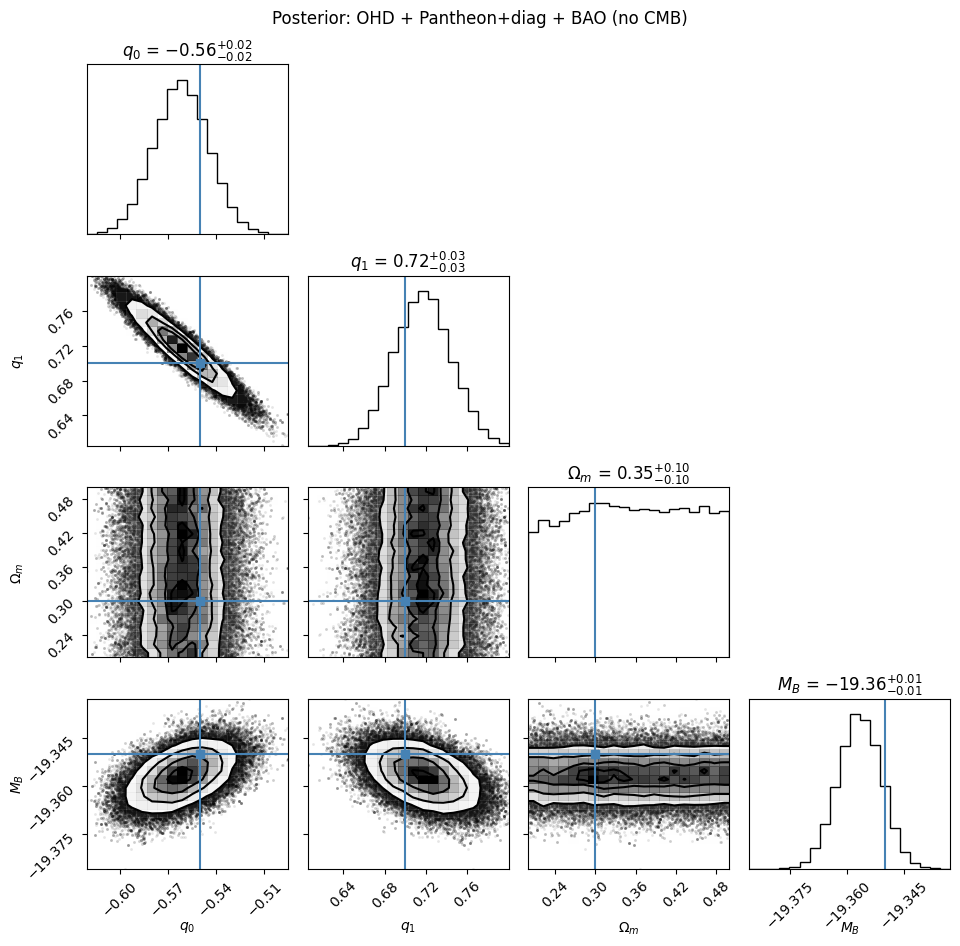

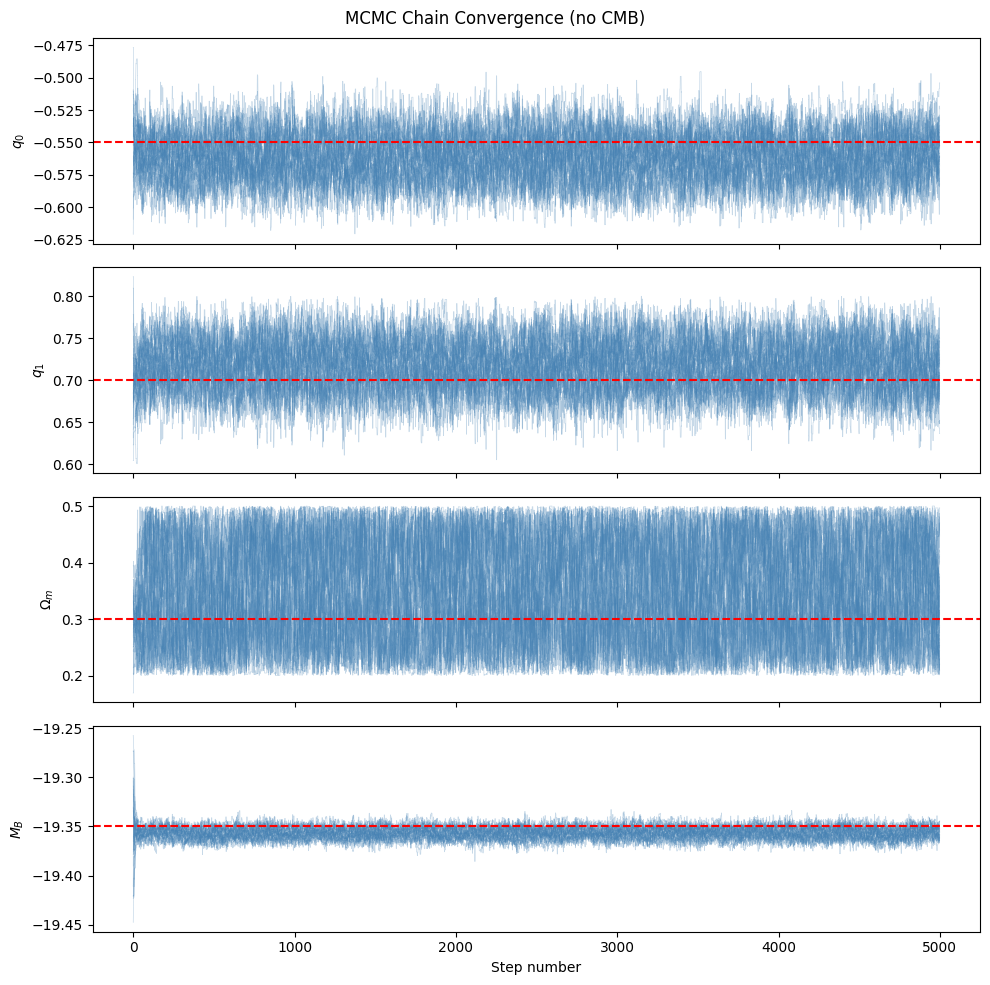


Done.


In [1]:
# =============================================================================
# OHD + Pantheon+ (diagonal) + DESI BAO
# Model: Weyl-type f(Q,T) gravity (q0, q1, Om0, M_B)
# No CMB – gives realistic uncertainties.
# =============================================================================

import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Cosmological functions (f(Q,T) model)
# -----------------------------------------------------------------------------

def hubble_z(z, q0, q1, H0=70):
    return H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1/2)

def comoving_distance(z, q0, q1, H0=70):
    c = 299792.458
    if np.isscalar(z):
        def integrand(zp): return c / hubble_z(zp, q0, q1, H0)
        return quad(integrand, 0, z)[0]
    else:
        res = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp): return c / hubble_z(zp, q0, q1, H0)
            res[i] = quad(integrand, 0, zi)[0]
        return res

def angular_diameter_distance(z, q0, q1, H0=70):
    return comoving_distance(z, q0, q1, H0) / (1 + z)

def luminosity_distance(z, q0, q1, H0=70):
    c = 299792.458
    if np.isscalar(z):
        def integrand(zp): return 1.0 / hubble_z(zp, q0, q1, H0)
        return c * (1 + z) * quad(integrand, 0, z)[0]
    else:
        dL = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp): return 1.0 / hubble_z(zp, q0, q1, H0)
            dL[i] = c * (1 + zi) * quad(integrand, 0, zi)[0]
        return dL

def distance_modulus_theory(z, q0, q1, H0=70):
    return 5 * np.log10(luminosity_distance(z, q0, q1, H0)) + 25

# -----------------------------------------------------------------------------
# 2. Load data
# -----------------------------------------------------------------------------

print("Loading data...")

# OHD
ohd = np.loadtxt(r'C:\Users\mriga\Downloads\OHD.txt')
z_ohd, H_ohd, H_err = ohd[:,0], ohd[:,1], ohd[:,2]
print(f"  OHD: {len(z_ohd)} points")

# DESI BAO
mean_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_mean.txt'
cov_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_cov.txt'
mean_data = np.loadtxt(mean_file, skiprows=1, dtype=str)
cov_bao = np.loadtxt(cov_file)

dv_data, dm_data, dh_data = [], [], []
for i, row in enumerate(mean_data):
    z = float(row[0]); val = float(row[1]); qty = row[2]; err = np.sqrt(cov_bao[i,i])
    if 'DV_over_rs' in qty: dv_data.append([z, val, err])
    elif 'DM_over_rs' in qty: dm_data.append([z, val, err])
    elif 'DH_over_rs' in qty: dh_data.append([z, val, err])
dv_data, dm_data, dh_data = map(np.array, [dv_data, dm_data, dh_data])
print(f"  DESI BAO: {len(dv_data)+len(dm_data)+len(dh_data)} measurements")

# Pantheon+ (diagonal errors – stable and fast)
def load_pantheon_diag(data_path):
    data = np.genfromtxt(data_path, names=True, dtype=None, encoding='utf-8')
    z = data['zCMB']
    mb = data['m_b_corr']
    mb_err = data['m_b_corr_err_DIAG']
    return z, mb, mb_err

pantheon_path = r'C:\Users\mriga\Downloads\Pantheon+SH0ES.dat'
z_sn, mb_sn, mb_err_sn = load_pantheon_diag(pantheon_path)
print(f"  Pantheon+ (diagonal): {len(z_sn)} supernovae")

# -----------------------------------------------------------------------------
# 3. Likelihood functions
# -----------------------------------------------------------------------------

C_LIGHT = 299792.458
RS_BAO = 147.5

def log_likelihood_OHD(params, z, H, H_err, H0=70):
    q0, q1, Om0, M_B = params
    H_model = H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1/2)
    chi2 = np.sum(((H - H_model) / H_err)**2)
    return -0.5 * chi2

def log_likelihood_pantheon(params, z, mb, mb_err, H0=70):
    q0, q1, Om0, M_B = params
    mu = distance_modulus_theory(z, q0, q1, H0)
    residuals = mb - M_B - mu
    chi2 = np.sum((residuals / mb_err)**2)
    return -0.5 * chi2

def log_likelihood_BAO(params, dm, dh, dv, H0=70, rs=RS_BAO):
    q0, q1, Om0, M_B = params
    chi2 = 0.0
    for z, obs, err in dm:
        DC = comoving_distance(z, q0, q1, H0)
        chi2 += ((obs - DC/rs) / err)**2
    for z, obs, err in dh:
        H_val = hubble_z(z, q0, q1, H0)
        chi2 += ((obs - (C_LIGHT/H_val)/rs) / err)**2
    for z, obs, err in dv:
        DC = comoving_distance(z, q0, q1, H0)
        DA = DC/(1+z)
        H_val = hubble_z(z, q0, q1, H0)
        DV = ((1+z)**2 * DA**2 * C_LIGHT * z / H_val) ** (1/3)
        chi2 += ((obs - DV/rs) / err)**2
    return -0.5 * chi2

def log_prior(params):
    q0, q1, Om0, M_B = params
    if (-0.8 < q0 < -0.4 and 0.5 < q1 < 0.8 and 0.2 < Om0 < 0.5 and -19.6 < M_B < -19.0):
        return 0.0
    return -np.inf

def log_posterior(params, z_ohd, H_ohd, H_err, z_sn, mb_sn, mb_err_sn,
                  dm_data, dh_data, dv_data, H0=70):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    logL = 0.0
    logL += log_likelihood_OHD(params, z_ohd, H_ohd, H_err, H0)
    logL += log_likelihood_pantheon(params, z_sn, mb_sn, mb_err_sn, H0)
    logL += log_likelihood_BAO(params, dm_data, dh_data, dv_data, H0)
    return lp + logL

# -----------------------------------------------------------------------------
# 4. MCMC
# -----------------------------------------------------------------------------

print("\nRunning MCMC (OHD + Pantheon+diag + BAO) – no CMB...")

n_walkers = 32
n_dim = 4
n_steps = 5000       # increase to 5000 for final publication
n_burn = 500

start_guess = np.array([-0.55, 0.70, 0.30, -19.35])
np.random.seed(42)
start_pos = start_guess + 0.05 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(
    n_walkers, n_dim, log_posterior,
    args=(z_ohd, H_ohd, H_err, z_sn, mb_sn, mb_err_sn,
          dm_data, dh_data, dv_data),
    kwargs={"H0": 70}
)

sampler.run_mcmc(start_pos, n_steps, progress=True)

# -----------------------------------------------------------------------------
# 5. Results
# -----------------------------------------------------------------------------

flat = sampler.get_chain(discard=n_burn, flat=True)

q0_m, q0_s = np.mean(flat[:,0]), np.std(flat[:,0])
q1_m, q1_s = np.mean(flat[:,1]), np.std(flat[:,1])
Om0_m, Om0_s = np.mean(flat[:,2]), np.std(flat[:,2])
MB_m, MB_s = np.mean(flat[:,3]), np.std(flat[:,3])

print("\n" + "="*60)
print("FINAL RESULTS (OHD + Pantheon+diag + BAO, no CMB)")
print("="*60)
print(f"q₀ = {q0_m:.3f} ± {q0_s:.3f}")
print(f"q₁ = {q1_m:.3f} ± {q1_s:.3f}")
print(f"Ω_m = {Om0_m:.3f} ± {Om0_s:.3f}")
print(f"M_B = {MB_m:.3f} ± {MB_s:.3f}")

def q_of_z(z, q0, q1):
    return q0 + q1 * z*(1+z)/(1+z**2)
z_test = np.linspace(0, 2, 200)
q_vals = q_of_z(z_test, q0_m, q1_m)
zt = z_test[np.argmin(np.abs(q_vals))]
print(f"Transition redshift (q=0): z_t ≈ {zt:.2f}")

# -----------------------------------------------------------------------------
# 6. Plots
# -----------------------------------------------------------------------------

labels = [r"$q_0$", r"$q_1$", r"$\Omega_m$", r"$M_B$"]
fig = corner.corner(flat, labels=labels, truths=start_guess, show_titles=True)
plt.suptitle("Posterior: OHD + Pantheon+diag + BAO (no CMB)")
plt.tight_layout()
plt.show()

chain = sampler.get_chain()
fig, axes = plt.subplots(n_dim, 1, figsize=(10, 10), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(chain[:, :, i], alpha=0.3, color='steelblue', lw=0.5)
    ax.axhline(start_guess[i], color='red', linestyle='--', label='Start')
    ax.set_ylabel(label)
axes[-1].set_xlabel("Step number")
plt.suptitle("MCMC Chain Convergence (no CMB)")
plt.tight_layout()
plt.show()